# Fourchette de prix + incertitude (french-second-hand-cars)

**Exigence produit OscarIA** : au lieu d'un prix ponctuel, une **fourchette** « entre X et Y € »
dont la largeur = l'incertitude, par **régression quantile** + **calibration conforme**
(couverture visée : 80 %).

> Périmètre produit **≤ 50 000 €** (justification chiffrée : fiche de décision 0002), appliqué
> dès le nettoyage (`clean_cars`). `SEUIL` reste réglable ci-dessous.

In [1]:
import sys, math
from pathlib import Path
sys.path.insert(0, "../../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import importlib, features; importlib.reload(features)  # recharge src si édité
from features import clean_cars, load_premium_table, add_brand_features

SEUIL = 50_000      # >>> RÉGLAGE : périmètre produit en euros <<<
ALPHA = 0.20        # 1 - couverture visée -> 80 %

df = clean_cars("../../data/french-second-hand-cars/raw/French_second_hand_cars.csv",
                max_price=SEUIL)
df = add_brand_features(df, load_premium_table("../../references/premium_brand.csv"))

features_num = ["age", "kilometrage", "puissance_fisc",
                "nombredeportes", "nombredeplaces",
                "niveau", "boite_auto", "energie_code", "premiere_main"]
print(f"shape (périmètre ≤{SEUIL//1000}k):", df.shape)

shape (périmètre ≤50k): (2079, 56)


## 🟦 1. Double découpage

Pour la calibration conforme il faut **3 jeux** : **ajustement** (entraîne les modèles
quantile), **calibration** (mesure de combien élargir), **test** (évaluation finale).
La fréquence du modèle exact (`modele_freq`) est apprise sur le jeu d'**ajustement uniquement**.

In [2]:
data = df[features_num + ["modele", "price"]].dropna(subset=["price"])
X, y = data[features_num + ["modele"]], data["price"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
X_fit, X_cal, y_fit, y_cal = train_test_split(X_tr, y_tr, test_size=0.25, random_state=42)

freq_fit = X_fit["modele"].value_counts()
def with_freq(Xd):
    return Xd[features_num].assign(modele_freq=Xd["modele"].map(freq_fit).fillna(0))
X_fit, X_cal, X_te = with_freq(X_fit), with_freq(X_cal), with_freq(X_te)
print("fit:", len(X_fit), "| calibration:", len(X_cal), "| test:", len(X_te))

fit: 1247 | calibration: 416 | test: 416


## 🟩 2. Trois modèles quantile

Chacun optimise une **pinball loss** (`loss="quantile"`) : q10 = borne basse, q50 = médiane,
q90 = borne haute. Fourchette = [q10, q90] → ~80 % de couverture visée.

In [3]:
def fit_quantile(q):
    return HistGradientBoostingRegressor(loss="quantile", quantile=q,
                                         random_state=42).fit(X_fit, y_fit)
m10, m50, m90 = fit_quantile(0.10), fit_quantile(0.50), fit_quantile(0.90)

def bornes(Xd):
    lo, hi = m10.predict(Xd), m90.predict(Xd)
    return np.minimum(lo, hi), np.maximum(lo, hi)   # garde-fou anti-croisement

lo_raw, hi_raw = bornes(X_te)
cov_raw = ((y_te.values >= lo_raw) & (y_te.values <= hi_raw)).mean() * 100
print(f"Couverture BRUTE : {cov_raw:.1f} %  (visé 80 %) — trop optimiste, on calibre.")

Couverture BRUTE : 65.6 %  (visé 80 %) — trop optimiste, on calibre.


## 🟩 3. Calibration conforme (CQR)

Sur le jeu de calibration : `score = max(q10 − prix, prix − q90)` (positif = hors fourchette).
Le quantile 80 % de ces scores = **coussin Q** ajouté de chaque côté → couverture ~80 %
garantie en moyenne sur données neuves.

In [4]:
lo_cal, hi_cal = bornes(X_cal)
s = np.maximum(lo_cal - y_cal.values, y_cal.values - hi_cal)
k = min(math.ceil((len(s) + 1) * (1 - ALPHA)), len(s))
Q = np.sort(s)[k - 1]

lo, hi = lo_raw - Q, hi_raw + Q
med = m50.predict(X_te)
cov = ((y_te.values >= lo) & (y_te.values <= hi)).mean() * 100
largeur = hi - lo

print(f"coussin Q = {Q:,.0f} €")
print(f"Couverture CALIBRÉE : {cov:.1f} %  (visé 80 %)  [brute: {cov_raw:.1f} %]")
print(f"Largeur médiane     : {np.median(largeur):,.0f} €  ({np.median(largeur)/np.median(y_te)*100:.0f} % du prix médian)")
print(f"Modèle médian (q50) : MAE {mean_absolute_error(y_te, med):,.0f} € | R² {r2_score(y_te, med):.3f}")

coussin Q = 1,228 €
Couverture CALIBRÉE : 78.6 %  (visé 80 %)  [brute: 65.6 %]
Largeur médiane     : 9,745 €  (42 % du prix médian)
Modèle médian (q50) : MAE 3,074 € | R² 0.823


## 🟥 4. Exemples + bande d'incertitude

✓ réel   5,780 €  ->  [  4,254 ;   9,159] €  (large 4,905 €)
✓ réel  23,080 €  ->  [ 19,884 ;  31,969] €  (large 12,085 €)
✗ réel  49,970 €  ->  [ 34,151 ;  47,304] €  (large 13,153 €)


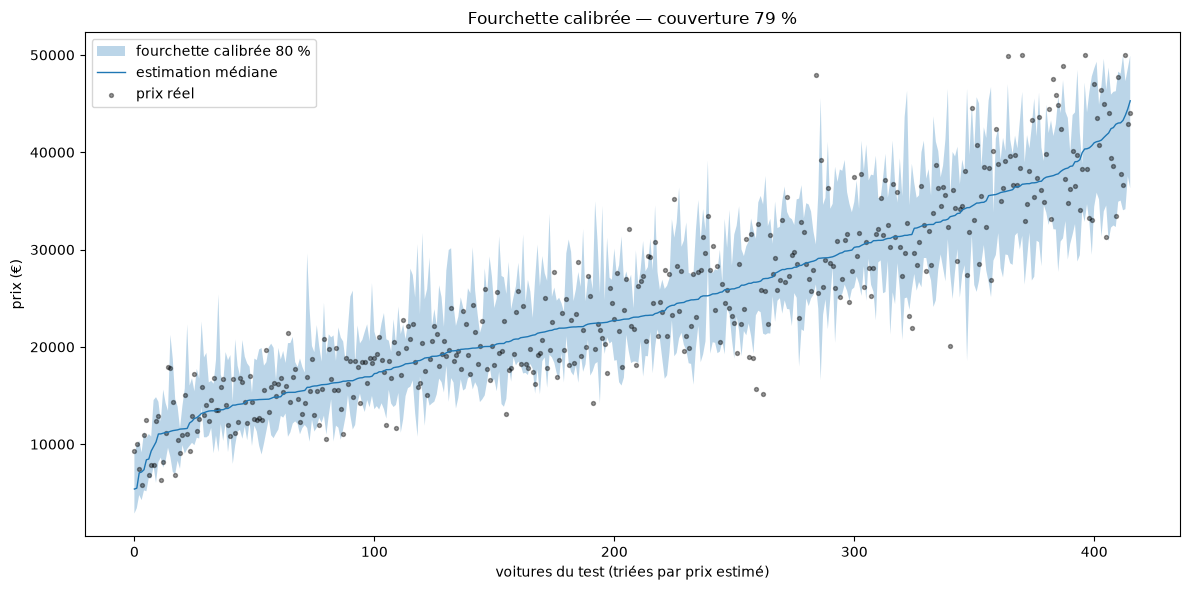

In [5]:
idx = [y_te.values.argmin(),
       np.abs(y_te.values - np.median(y_te)).argmin(),
       y_te.values.argmax()]
for i in idx:
    ok = "✓" if lo[i] <= y_te.values[i] <= hi[i] else "✗"
    print(f"{ok} réel {y_te.values[i]:>7,.0f} €  ->  [{lo[i]:>7,.0f} ; {hi[i]:>7,.0f}] €  (large {hi[i]-lo[i]:,.0f} €)")

ordre = np.argsort(med); xs = np.arange(len(ordre))
plt.figure(figsize=(12, 6))
plt.fill_between(xs, lo[ordre], hi[ordre], alpha=0.3, label="fourchette calibrée 80 %")
plt.plot(xs, med[ordre], color="C0", lw=1, label="estimation médiane")
plt.scatter(xs, y_te.values[ordre], s=8, color="k", alpha=0.4, label="prix réel")
plt.xlabel("voitures du test (triées par prix estimé)"); plt.ylabel("prix (€)")
plt.title(f"Fourchette calibrée — couverture {cov:.0f} %")
plt.legend(); plt.tight_layout(); plt.show()

## Lecture (BC04)

- **Périmètre** : décision chiffrée et assumée (fiche 0002), appliquée dès le nettoyage.
- **Fourchette brute trop optimiste** → la calibration conforme la corrige ; la **couverture est
  mesurée, pas proclamée** (bruit d'échantillonnage de quelques points attendu, ~400 voitures).
- **La largeur varie par voiture** = le modèle avoue quand il doute (explicabilité).
- **Limites** : couverture globale (peut varier par segment) ; coussin symétrique ; données
  100 % vendeurs professionnels (fiche 0005) — prix pros ≠ prix particuliers.